In [69]:
# Deep Learning Lab
# Exercise 2
# Implementation of a Multi-Layer Perceptron (MLP) for Multi-Class Image Classification

# Importing necessary modules
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import pandas as pd

In [ ]:
# Task 1 : Dataset Exploration
# Loading data and splitting it in test/train split
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# Displaying dimensions of dataset
print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


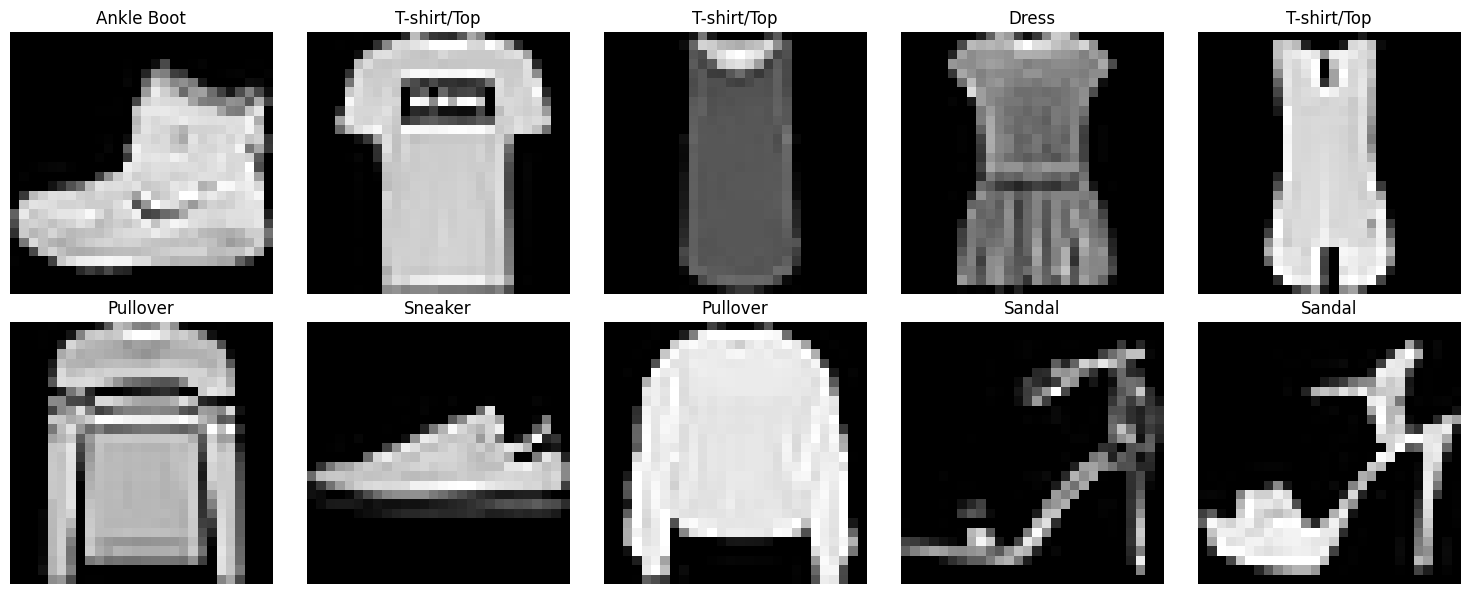

In [ ]:
# Displaying each class sample image
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]
plt.figure(figsize=(15,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

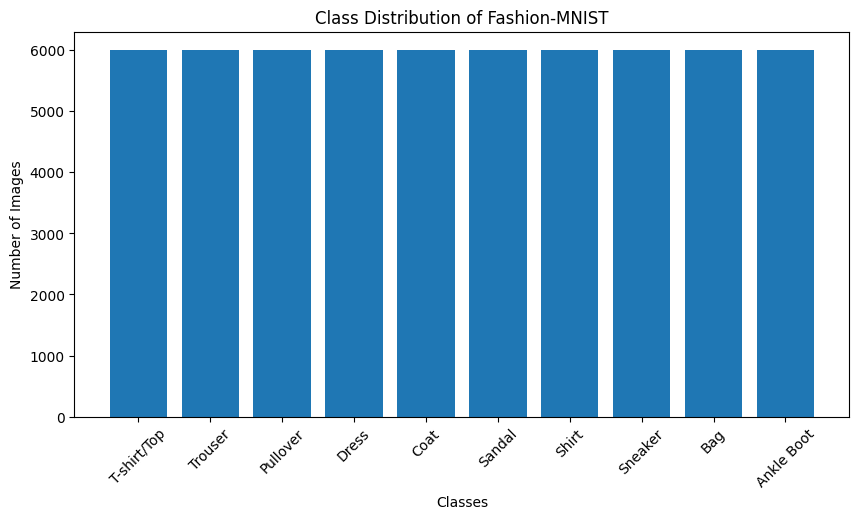

In [ ]:
# Distribution of each class in dataset
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.title("Class Distribution of Fashion-MNIST")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Task 2 : Data Preprocessing
# Flattening images
from tensorflow.keras.utils import to_categorical
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
#Dimensions after preprocessing
print("After Preprocessing")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

After Preprocessing
x_train: (60000, 784)
x_test : (10000, 784)
y_train: (60000, 10)
y_test : (10000, 10)


In [ ]:
# Task 3 : Model Construction
# Importing necessary modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [79]:
# Constructing the MLP architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_115"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_297 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_298 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_299 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# Task 4 : Model Training
# Compiling the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Training the model
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8158 - loss: 0.5160 - val_accuracy: 0.8401 - val_loss: 0.4435
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8607 - loss: 0.3776 - val_accuracy: 0.8652 - val_loss: 0.3750
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8778 - loss: 0.3364 - val_accuracy: 0.8736 - val_loss: 0.3489
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8838 - loss: 0.3149 - val_accuracy: 0.8764 - val_loss: 0.3391
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8892 - loss: 0.2974 - val_accuracy: 0.8758 - val_loss: 0.3393
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8958 - loss: 0.2807 - val_accuracy: 0.8791 - val_loss: 0.3412
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8979 - loss: 0.2693 - val_accuracy: 0.8790 - val_loss: 0.3410
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9030 - loss: 0.2583 - 

In [81]:
# Task 5 : Model Evaluation
# Testing the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8895 - loss: 0.3683
Test Loss: 0.3683003783226013
Test Accuracy: 0.8895000219345093
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [82]:
# Importing evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [83]:
# Evaluation
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix")
print(cm)

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

Accuracy : 0.8895
Precision: 0.891816238529155
Recall   : 0.8895
F1 Score : 0.8901089640437317
Confusion Matrix
[[803   0  14  28   4   1 141   0   9   0]
 [  1 977   0  16   1   0   4   0   1   0]
 [ 13   1 793  14  81   1  92   0   5   0]
 [  7   4  12 909  30   0  33   0   5   0]
 [  0   1  90  31 793   0  78   0   7   0]
 [  0   0   0   1   0 966   0  20   2  11]
 [ 75   0  66  35  50   1 766   0   7   0]
 [  0   0   0   0   0   9   0 955   0  36]
 [  5   0   2   3   3   2   9   5 971   0]
 [  0   0   0   0   0   7   1  30   0 962]]
              precision    recall  f1-score   support

 T-shirt/Top       0.89      0.80      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.81      0.79      0.80      1000
       Dress       0.88      0.91      0.89      1000
        Coat       0.82      0.79      0.81      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.68      0.77      0.72      1000
     Sneaker       0.95 

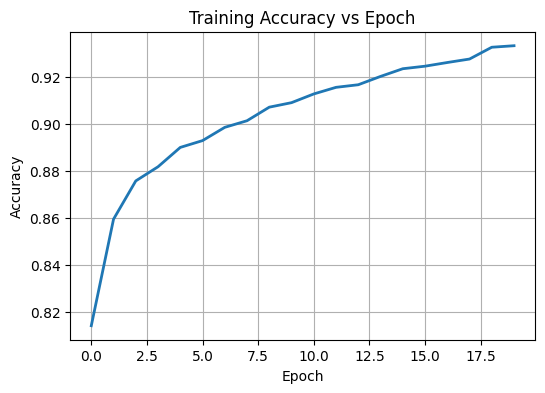

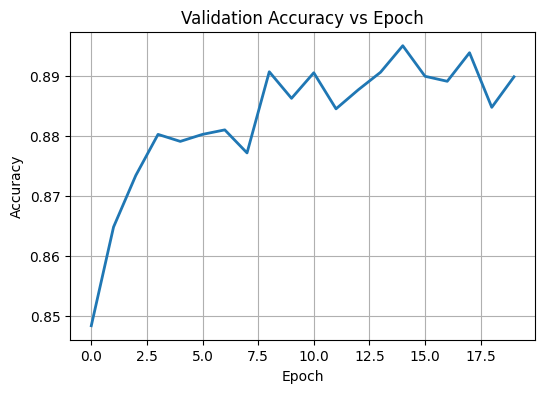

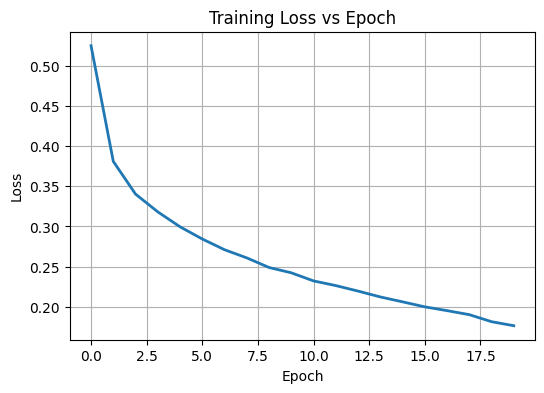

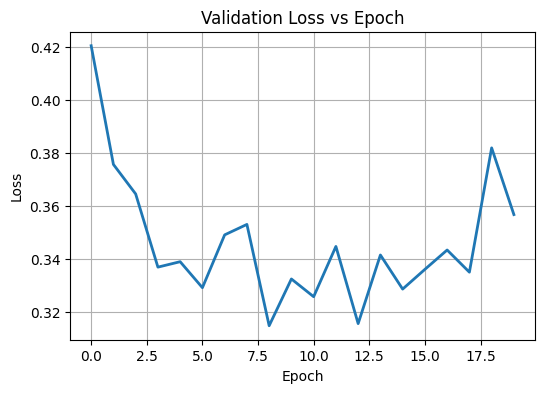

<Figure size 800x800 with 0 Axes>

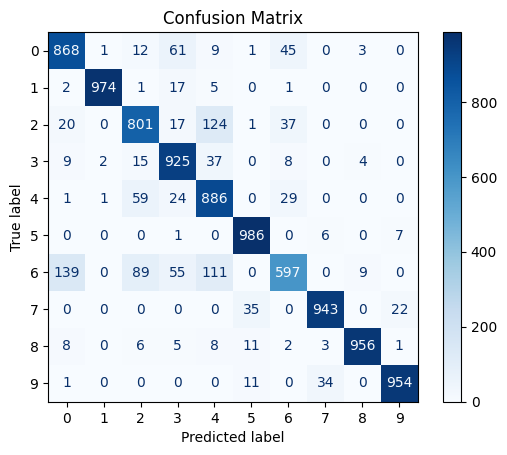

In [68]:
# Plots to give us more insight
from sklearn.metrics import ConfusionMatrixDisplay

# Training Accuracy v Epoch
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], linewidth=2)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Validation Accuracy v Epoch
plt.figure(figsize=(6,4))
plt.plot(history.history['val_accuracy'], linewidth=2)
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Training Loss v Epoch
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], linewidth=2)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Validation Loss v Epoch
plt.figure(figsize=(6,4))
plt.plot(history.history['val_loss'], linewidth=2)
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Confusion Matrix
y_pred = best_model.predict(x_test).argmax(axis=1)
y_true = y_test.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()



In [ ]:
# Additional Tasks
# Hyperparameter Optimization
# Importing necessary modules
from tensorflow.keras.layers import Input, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# Creating model function
def create_model(hidden_layers=2,
                 neurons=128,
                 learning_rate=0.001,
                 optimizer="adam",
                 activation="relu",
                 dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for i in range(hidden_layers):
        model.add(Dense(neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation="softmax"))
    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
# Wrapping
clf = KerasClassifier(
    model=create_model,
    verbose=0
)

# Search Space
param_dist = {
    "model__hidden_layers":[1,2,3],
    "model__neurons":[32,64,128,256],
    "model__learning_rate":[0.1,0.01,0.001],
    "model__optimizer":[
        "sgd",
        "adam",
        "rmsprop"
    ],
    "model__activation":[
        "relu",
        "tanh",
        "sigmoid"
    ],
    "model__dropout_rate":[
        0.0,
        0.2,
        0.5
    ],
    "batch_size":[16,32,64,128],
    "epochs":[10,20,30]
}

In [ ]:
# Setting up Random Search
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
    scoring="accuracy",
    n_jobs=1
)

In [ ]:
# Training models
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.4min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.4min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.4min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.3min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neur

RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x79c326f3b600>, verbose=0),
                   n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__neurons': [32, 64, 128, 256],
                                        'model__optimizer': ['sgd', 'adam',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy', verbose=2)

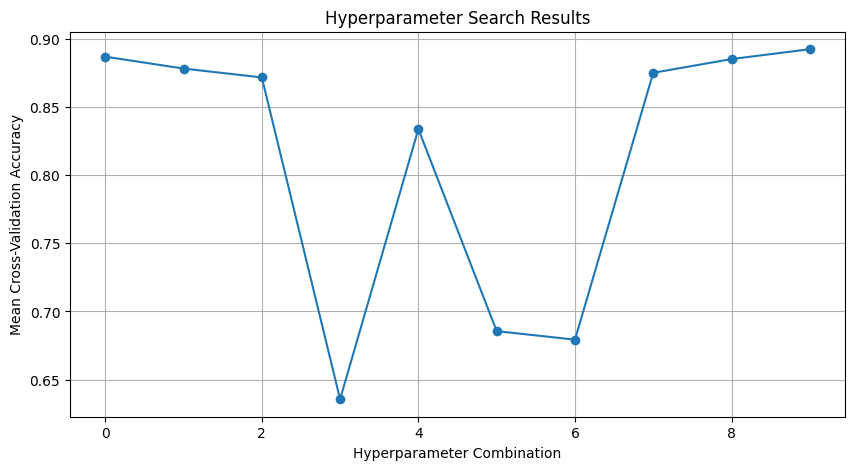

In [71]:
# Plotting each run accuracy
results = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(10,5))
plt.plot(results["mean_test_score"], marker='o')
plt.title("Hyperparameter Search Results")
plt.xlabel("Hyperparameter Combination")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.grid(True)
plt.show()

In [ ]:
# Evaluation
print("\nBest Parameters\n")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy\n")
print(random_search.best_score_)

best_model = random_search.best_estimator_


Best Parameters

{'model__optimizer': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 32}

Best Cross Validation Accuracy

0.8923666666666665


In [76]:
# Testing
y_pred = best_model.predict(x_test).argmax(axis=1)

test_accuracy = accuracy_score(
    y_test.argmax(axis=1),
    y_pred
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.889


In [74]:
# Storing hyperparameters of optimized model
best_params = random_search.best_params_

optimized_model = create_model(
    hidden_layers=best_params["model__hidden_layers"],
    neurons=best_params["model__neurons"],
    learning_rate=best_params["model__learning_rate"],
    optimizer=best_params["model__optimizer"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"]
)

# Training
optimized_history = optimized_model.fit(
    x_train,
    y_train,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7953 - loss: 0.5704 - val_accuracy: 0.8320 - val_loss: 0.4490
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8560 - loss: 0.3956 - val_accuracy: 0.8593 - val_loss: 0.3798
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8699 - loss: 0.3556 - val_accuracy: 0.8618 - val_loss: 0.3685
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8795 - loss: 0.3269 - val_accuracy: 0.8683 - val_loss: 0.3562
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8848 - loss: 0.3100 - val_accuracy: 0.8745 - val_loss: 0.3394
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8916 - loss: 0.2916 - val_accuracy: 0.8773 - val_loss: 0.3293
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8983 - loss: 0.2735 - val_accuracy: 0.8839 - val_loss: 0.3195
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9028 - loss: 0.2608 -

In [75]:
y_pred = optimized_model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Optimized Model")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8827
Precision: 0.883000261608997
Recall   : 0.8827
F1 Score : 0.8809328844431431
Confusion Matrix
[[869   2  21  20   7   1  65   0  15   0]
 [  1 971   3  18   6   0   0   0   1   0]
 [ 14   1 830   9 106   0  35   0   5   0]
 [ 19  14  18 872  53   1  17   0   6   0]
 [  1   1  89  15 854   0  38   0   2   0]
 [  0   0   0   0   0 974   0  16   1   9]
 [151   2 110  36  94   0 589   0  17   1]
 [  0   0   0   0   0  26   0 945   0  29]
 [  4   0   6   2   5   4   4   4 971   0]
 [  0   0   0   0   0  17   1  30   0 952]]
              precision    recall  f1-score   support

 T-shirt/Top       0.82      0.87      0.84      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.77      0.83      0.80      1000
       Dress       0.90      0.87      0.88      1000
        Coat       0.76      0.85      0.80      1000
      Sandal       0.95      0.97      0.96      1000
       Shirt       0.79      0.59      0.67      1000
     Sneaker       0.95 

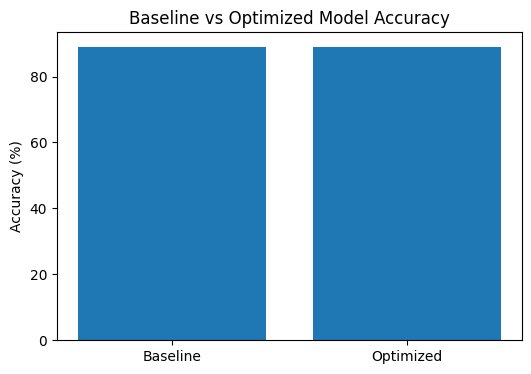

In [ ]:
# Comparison between baseline and optimized
baseline_acc = history.history["val_accuracy"][-1] * 100
optimized_acc = test_accuracy * 100

plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Optimized"], [baseline_acc, optimized_acc])

plt.ylabel("Accuracy (%)")
plt.title("Baseline vs Optimized Model Accuracy")

plt.show()

In [ ]:
# Logic Gates with MLP
# Common input for AND, OR, XOR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)
\
# Training function
def train_gate(gate_name, y):
    model = Sequential([
        Dense(4, activation='relu', input_shape=(2,)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.fit(X, y, epochs=1000, verbose=1)
    pred = (model.predict(X, verbose=1) > 0.5).astype(int)
    print(f"\n{gate_name} Gate")
    print("----------------")
    for inp, out in zip(X, pred):
        print(f"{inp} -> {out[0]}")

In [ ]:
# Logic Gates - AND, OR
y_and = np.array([[0], [0], [0], [1]], dtype=np.float32)
train_gate("AND", y_and)
y_or = np.array([[0], [1], [1], [1]], dtype=np.float32)
train_gate("OR", y_or)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7282
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5000 - loss: 0.7271
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5000 - loss: 0.7261
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5000 - loss: 0.7251
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5000 - loss: 0.7241
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5000 - loss: 0.7230
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5000 - loss: 0.7220
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5000 - loss: 0.7210
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.5000 - loss: 0.7200
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5000 - loss: 0.7190
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.5000 - loss: 0.7180
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - a

In [ ]:
# NOT Gate
X_not = np.array([
    [0],
    [1]
], dtype=np.float32)
y = np.array([[1], [0]], dtype=np.float32)
model = Sequential([
        Dense(4, activation='relu', input_shape=(1,)),
        Dense(1, activation='sigmoid')
    ])

model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
model.fit(X_not, y, epochs=1000, verbose=1)
pred = (model.predict(X_not, verbose=1) > 0.5).astype(int)
print("\nNOT Gate")
print("---------")
for inp, out in zip(X_not, pred):
      print(f"{inp} -> {out[0]}")

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step - accuracy: 0.5000 - loss: 0.5685
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5000 - loss: 0.5676
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.5668
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.5659
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.5650
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.5641
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.5631
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.5622
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.5613
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.5605
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.5596
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy

In [ ]:
# XOR Gate
y_xor = np.array([[0], [1], [1], [0]], dtype=np.float32)
train_gate("XOR", y_xor)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step - accuracy: 0.5000 - loss: 0.7204
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.7202
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 0.7200
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5000 - loss: 0.7199
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5000 - loss: 0.7197
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.7195
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5000 - loss: 0.7194
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 0.7192
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 0.7190
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.7189
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: 0.7187
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accurac